In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

In [26]:
import pandas as pd

df = pd.read_csv("../dataset/dataset/sample_dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [27]:
os.makedirs("charts", exist_ok=True)
os.makedirs("dashboard", exist_ok=True)
os.makedirs("sql_queries", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [28]:
conn = sqlite3.connect("../superstore.db")

df.to_sql("superstore", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [29]:
query = """
SELECT
      "Product Name",
      SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""
top_products = pd.read_sql_query(query, conn)

top_products

,Product Name,Total_Sales
0,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300
1,Bretford CR4500 Series Slim Rectangular Table,2002.2075
2,Chromcraft Rectangular Conference Tables,1706.1840
3,Hunt BOSTON Model 1606 High-Volume Electric Pe...,1113.0240
4,GE 30524EE4,1097.5440
5,AT&T CL83451 4-Handset Telephone,1029.9500
6,Konftel 250 Conference phone - Charcoal black,911.4240
7,Mitel 5320 IP Phone VoIP phone,907.1520
8,High-Back Leather Manager's Chair,831.9360
9,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400


In [30]:
top_products.to_csv("sql_queries/top_products.csv", index=False)

In [31]:
query = """
SELECT "Product Name", SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)

top_products.head()

,Product Name,Total_Sales
0,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300
1,Bretford CR4500 Series Slim Rectangular Table,2002.2075
2,Chromcraft Rectangular Conference Tables,1706.1840
3,Hunt BOSTON Model 1606 High-Volume Electric Pe...,1113.0240
4,GE 30524EE4,1097.5440


In [32]:
pd.read_sql("PRAGMA table_info(superstore);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Row ID,INTEGER,0,None,0
1,1,Order ID,TEXT,0,None,0
2,2,Order Date,TEXT,0,None,0
3,3,Ship Date,TEXT,0,None,0
4,4,Ship Mode,TEXT,0,None,0
5,5,Customer ID,TEXT,0,None,0
6,6,Customer Name,TEXT,0,None,0
7,7,Segment,TEXT,0,None,0
8,8,Country,TEXT,0,None,0
9,9,City,TEXT,0,None,0


In [33]:
query = """
SELECT
      Region,
        SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sales = pd.read_sql_query(query, conn)

region_sales

,Region,Total_Sales
0,West,7402.6220
1,East,5269.0520
2,Central,4942.3602
3,South,3890.4975


In [34]:
import os
os.makedirs("sql_queries", exist_ok=True)

region_sales.to_csv("sql_queries/region_sales.csv", index=False)

In [35]:
region_sales.to_csv("region_sales.csv", index=False)

In [36]:
query = """
SELECT Region, SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Region;
"""

region_sales = pd.read_sql_query(query, conn)

In [37]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql_query(query, conn)

,name
0,superstore


In [38]:
query = """
SELECT Category, SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC
"""
category_profit = pd.read_sql_query(query, conn)

category_profit

,Category,Total_Profit
0,Technology,785.6685
1,Office Supplies,763.7871
2,Furniture,-1651.3463


In [39]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../superstore.db")

In [40]:
category_profit.to_csv("../sql_queries/category_profit.csv", index=False)

In [41]:
category_profit = df.groupby("Category", as_index=False)["Profit"].sum()


<function matplotlib.pyplot.show(close=None, block=None)>

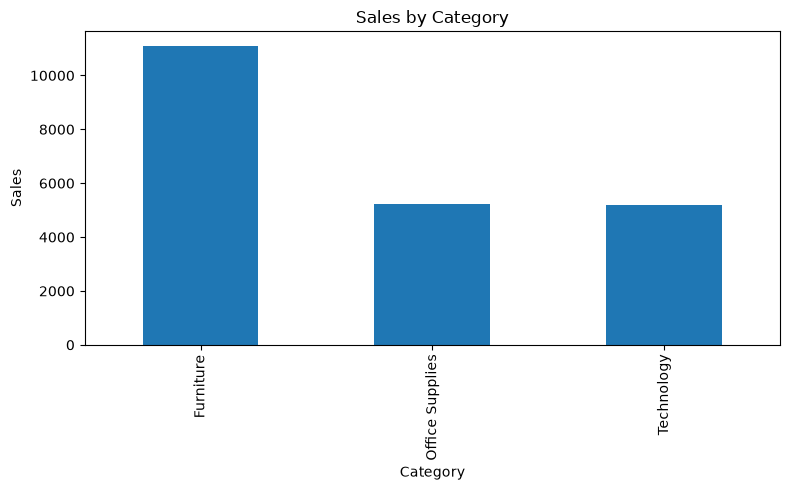

In [42]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../charts/sales_by_category.png")
plt.show

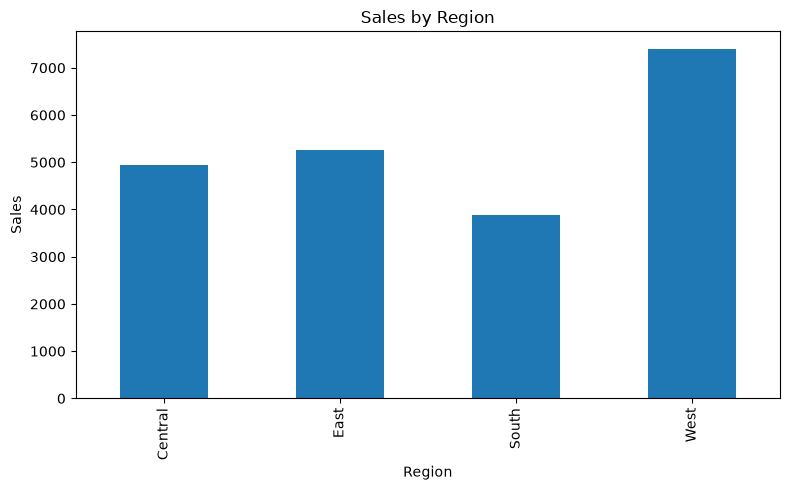

In [43]:
region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("../charts/sales_by_region.png")
plt.show()

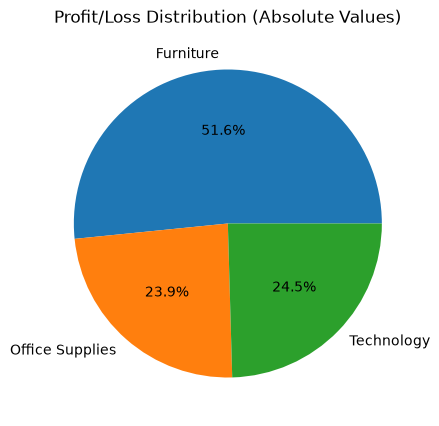

In [44]:
profit = df.groupby("Category")["Profit"].sum().abs()

plt.figure(figsize=(8,5))
profit.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Profit/Loss Distribution (Absolute Values)")
plt.savefig("../charts/profit_by_category.png")
plt.show()


In [45]:
import os
print(os.listdir("../dataset"))

['dataset']


In [46]:
import os

print("Current folder:", os.getcwd())
print("Files in current folder:", os.listdir())
print("Files in parent folder:", os.listdir(".."))

Current folder: c:\Users\saini\OneDrive\Desktop\Task1-DataAnalytics\Task1-DataAnalytics\notebooks
Files in current folder: ['charts', 'dashboard', 'region_sales.csv', 'sql_queries', 'task3_dashboard.ipynb']
Files in parent folder: ['.git', 'bar_chart.png.png', 'charts', 'correlation_heatmap.png', 'dashboard', 'dataset', 'discount_vs_profit.png', 'monthly sales trend.png', 'notebooks', 'pie_chart.png.png', 'profit_by_region.png', 'README.md', 'sales_by_category.png', 'sales_histogram.png', 'sales_vs_profit.png', 'segment_analysis.sql', 'sql_queries', 'superstore.db', 'Task1.ipynb', 'task2.ipynb', 'top_10_products_sales.png', 'top_products.png']


In [47]:
import pandas as pd
import matplotlib.pyplot as plt


In [48]:
html = """
<!DOCTYPE html>
<html>

<head>
<title>Superstore Sales Dashboard</title>

<style>
/* You can add your CSS styling here */
</style>
</head>

<body>
<h1>Superstore Sales Dashboard</h1>

<!-- Example: Pie chart or other visualizations can be embedded here -->
<div id="chart">
    <!-- Chart output will be inserted here -->
</div>

</body>
</html>
"""
